## 1. Optimización del Modelo Probabilístico (GMM)
**Objetivo:** Determinar el número óptimo de componentes Gaussianos ($K$) que mejor representen la distribución del hiperespacio acústico $\mathbb{R}^{64}$. Se utiliza el **Coeficiente de Silhouette** como métrica de validación interna.

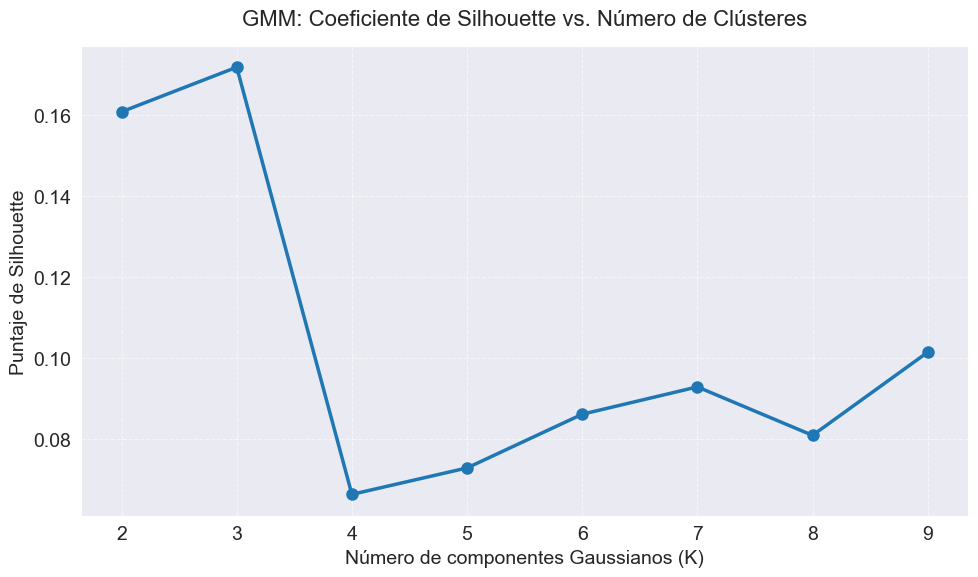

El número óptimo de clústeres es K = 3 con un Silhouette de 0.172


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

# 1. Configuración estricta de tamaño de fuente para evitar penalizaciones (>= 14)
plt.rcParams.update({'font.size': 14})

# 2. Carga de datos y preprocesamiento
# Asegúrate de que el archivo 'eco_acoustic_train.csv' esté en la misma carpeta
df = pd.read_csv('eco_acoustic_train.csv')

# Extraer únicamente las 64 columnas correspondientes a las características espectrales (Mel)
X = df.loc[:, 'mel_0':'mel_63']

# Estandarizar el espacio vectorial
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Cálculo del Coeficiente de Silhouette iterando el número de clústeres en GMM
k_values = range(2, 10)
silhouette_scores = []

for k in k_values:
    # Definir y entrenar el modelo probabilístico (GMM)
    gmm = GaussianMixture(n_components=k, random_state=42)
    labels = gmm.fit_predict(X_scaled)
    
    # Calcular y almacenar el Coeficiente de Silhouette
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

# 4. Generación de la visualización geométrica
plt.figure(figsize=(10, 6))
plt.plot(k_values, silhouette_scores, marker='o', linestyle='-', color='#1f77b4', linewidth=2.5, markersize=8)

# Configuración de etiquetas y título con tamaño exigido
plt.title('GMM: Coeficiente de Silhouette vs. Número de Clústeres', fontsize=16, pad=15)
plt.xlabel('Número de componentes Gaussianos (K)', fontsize=14)
plt.ylabel('Puntaje de Silhouette', fontsize=14)

# Configuración de los ejes
plt.xticks(k_values, fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)

# 5. Guardar la gráfica para adjuntar en LaTeX
plt.tight_layout()
plt.savefig('silhouette_gmm.png', dpi=300, bbox_inches='tight')

# Mostrar la gráfica en el notebook
plt.show()

# Imprimir el valor óptimo en consola para verificación
mejor_k = k_values[silhouette_scores.index(max(silhouette_scores))]
print(f"El número óptimo de clústeres es K = {mejor_k} con un Silhouette de {max(silhouette_scores):.3f}")

## 2. Optimización Basada en Densidad (DBSCAN)
**Objetivo:** Explorar mediante una búsqueda en cuadrícula (Grid Search) los hiperparámetros de vecindad ($\epsilon$) y densidad mínima ($MinPts$) para identificar clústeres orgánicos y aislar el ruido espacial. Se visualiza la convergencia mediante un mapa de calor del Coeficiente de Silhouette.

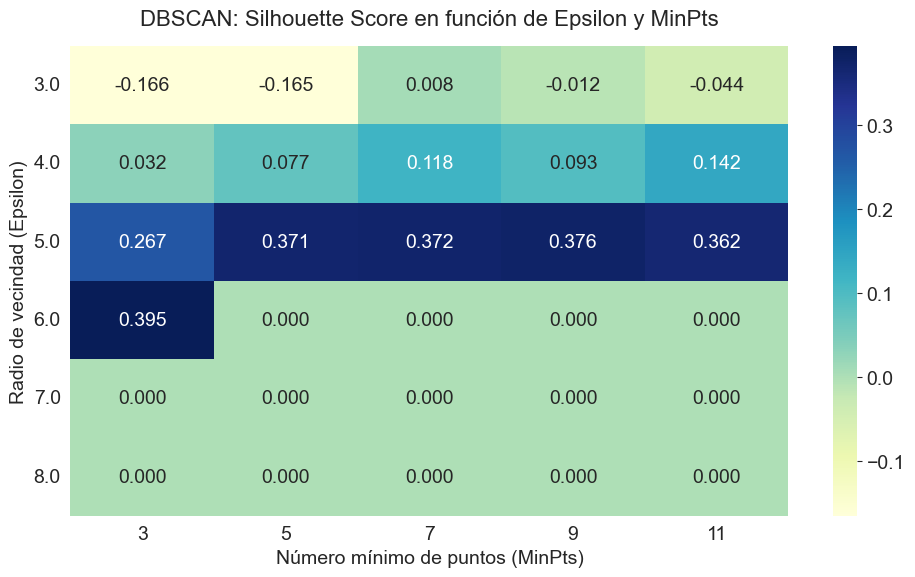

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# Configuración estricta de tamaño de fuente
plt.rcParams.update({'font.size': 14})

# Carga y estandarización (Si ya lo corriste arriba, no pasa nada, es para asegurar)
df = pd.read_csv('eco_acoustic_train.csv')
X = df.loc[:, 'mel_0':'mel_63']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Definir rangos para la cuadrícula de hiperparámetros
eps_values = np.arange(3.0, 9.0, 1.0)
min_samples_values = range(3, 12, 2)

# Matriz para guardar los resultados
results = np.zeros((len(eps_values), len(min_samples_values)))

# Iterar sobre todas las combinaciones
for i, eps in enumerate(eps_values):
    for j, min_samples in enumerate(min_samples_values):
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_scaled)
        
        # Ignorar ruido (-1) para el conteo de clusters reales
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        
        # Silhouette solo se puede calcular si hay 2 o más clusters
        if n_clusters > 1:
            score = silhouette_score(X_scaled, labels)
            results[i, j] = score
        else:
            results[i, j] = 0.0 # 0 si no logra formar grupos válidos

# Generar el Mapa de Calor
plt.figure(figsize=(10, 6))
sns.heatmap(results, annot=True, fmt=".3f", cmap="YlGnBu", 
            xticklabels=min_samples_values, yticklabels=eps_values,
            annot_kws={"size": 14}) # Forzar tamaño de fuente en los números

plt.title('DBSCAN: Silhouette Score en función de Epsilon y MinPts', fontsize=16, pad=15)
plt.xlabel('Número mínimo de puntos (MinPts)', fontsize=14)
plt.ylabel('Radio de vecindad (Epsilon)', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14, rotation=0)

# 6. Guardar la gráfica
plt.tight_layout()
plt.savefig('silhouette_dbscan.png', dpi=300, bbox_inches='tight')
plt.show()

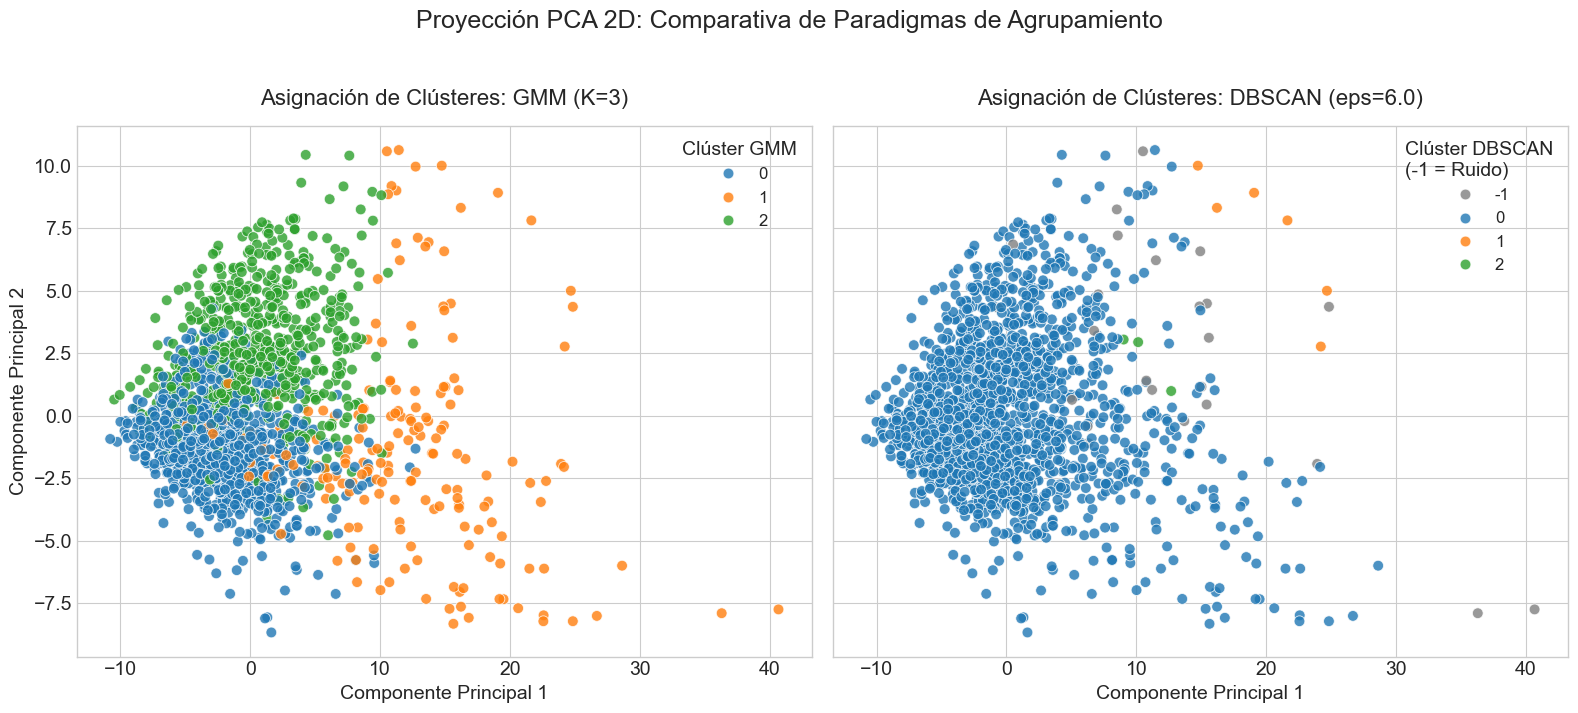

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.cluster import DBSCAN

# Configuración estricta de tamaño de fuente
plt.rcParams.update({'font.size': 14})
plt.style.use('seaborn-v0_8-whitegrid')

# Carga y estandarización
df = pd.read_csv('eco_acoustic_train.csv')
X = df.loc[:, 'mel_0':'mel_63']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Entrenar los mejores modelos
# GMM Óptimo (K=3)
gmm = GaussianMixture(n_components=3, random_state=42)
gmm_labels = gmm.fit_predict(X_scaled)

# DBSCAN Óptimo (eps=6.0, min_samples=3)
dbscan = DBSCAN(eps=6.0, min_samples=3)
dbscan_labels = dbscan.fit_predict(X_scaled)

# Reducción de Dimensionalidad con PCA a 2D para visualización
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Configurar la visualización comparativa (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)

# Paletas de colores
palette_gmm = sns.color_palette("tab10", n_colors=3)
# Para DBSCAN, el ruido (-1) lo pondremos de color gris
n_dbscan_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
palette_dbscan = sns.color_palette("tab10", n_colors=n_dbscan_clusters)
color_dict_dbscan = {i: palette_dbscan[i] for i in range(n_dbscan_clusters)}
color_dict_dbscan[-1] = (0.5, 0.5, 0.5, 0.5) # Gris semitransparente para el ruido

# Gráfica 1: GMM
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=gmm_labels, palette=palette_gmm, 
                ax=axes[0], s=60, alpha=0.8, legend='full')
axes[0].set_title('Asignación de Clústeres: GMM (K=3)', fontsize=16, pad=15)
axes[0].set_xlabel('Componente Principal 1', fontsize=14)
axes[0].set_ylabel('Componente Principal 2', fontsize=14)
axes[0].legend(title="Clúster GMM", fontsize=12, title_fontsize=14)

# Gráfica 2: DBSCAN
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=dbscan_labels, palette=color_dict_dbscan, 
                ax=axes[1], s=60, alpha=0.8, legend='full')
axes[1].set_title('Asignación de Clústeres: DBSCAN (eps=6.0)', fontsize=16, pad=15)
axes[1].set_xlabel('Componente Principal 1', fontsize=14)
axes[1].legend(title="Clúster DBSCAN\n(-1 = Ruido)", fontsize=12, title_fontsize=14)

# Ajustes finales y guardado
plt.suptitle('Proyección PCA 2D: Comparativa de Paradigmas de Agrupamiento', fontsize=18, y=1.02)
plt.tight_layout()
plt.savefig('comparativa_clusters.png', dpi=300, bbox_inches='tight')
plt.show()